# **TP - Introdução a Ciências de Dados - Animes**

## Grupo 12
- Aline Cristina Pinto - 2020031412
- Gabriel Oliveira Sant'ana - 2021039832
- Vinícius Gabriel Silva Ferreira -2021085010


# Configurações

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats as ss
import statsmodels.api as sm

In [2]:
plt.rcParams['figure.figsize']  = (16, 10)
#plt.rcParams['axes.labelsize']  = 20
#plt.rcParams['axes.titlesize']  = 20
#plt.rcParams['legend.fontsize'] = 20
#plt.rcParams['xtick.labelsize'] = 20
#plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['lines.linewidth'] = 4

plt.ion()
# plt.style.use('seaborn-colorblind')
plt.style.use('seaborn-v0_8-colorblind')

sns.set_theme(style="whitegrid")

# Bases de Dados

In [3]:
BASE_URL_DB = "https://raw.githubusercontent.com/viniciusgabrielsf/animes-data-science/main/databases/"

ANIMES_CSV_FILE_PATH = "animes.csv"


## DB My anime list

**Fonte**: [Anime Database 2022](https://www.kaggle.com/datasets/harits/anime-database-2022)


A base contém aproximadamente 21.460 registros de animes e 28 atributos, incluindo informações descritivas, estruturais e métricas de popularidade e avaliação. Para esse estudo, estamos interessados principalmente nos seguintes campos:

1. **ID**: ID do anime no MyAnimeList.net
2. **Title**: Nome original do anime
3. **Synonyms**: Nome(s) alternativo(s) do anime
4. **Japanese**: Título do anime em japonês
5. **English**: Título do anime em inglês
6. **Synopsis**: Sinopse do anime
7. **Type**: Tipo de anime
8. **Episodes**: Número de episódios do anime
9. **Status**: Status de exibição do anime (não exibido, em exibição ou já exibido)
10. **Start_Aired**: Data ou ano de início da exibição
11. **End_Aired**: Data ou ano de término da exibição
12. **Premiered**: Temporada de estreia
13. **Broadcast**: Horário de transmissão do anime
14. **Producers**: Lista de produtores
15. **Licensors**: Lista de licenciadores
16. **Studios**: Lista de estúdios
17. **Source**: Fonte de origem do anime
18. **Genres**: Lista de gêneros
19. **Themes**: Lista de temas
20. **Demographics**: Lista de demografias
21. **Duration_Minutes**: Duração total (em minutos) de cada episódio
22. **Rating**: Classificação etária
23. **Score**: Nota média do anime dada pelos usuários do MyAnimeList.net
24. **Scored_Users**: Número de usuários que avaliaram o anime
25. **Ranked**: Ranking baseado na nota
26. **Popularity**: Ranking baseado na popularidade (quantidade de usuários que adicionaram o anime à lista)
27. **Members**: Número de usuários que adicionaram o anime à lista
28. **Favorites**: Número de usuários que marcaram o anime como favorito





In [4]:
url_animes = f"{BASE_URL_DB}{ANIMES_CSV_FILE_PATH}"
df_animes = pd.read_csv(url_animes)

In [5]:
df_animes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21460 entries, 0 to 21459
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                21460 non-null  int64  
 1   Title             21460 non-null  object 
 2   Synonyms          21460 non-null  object 
 3   Japanese          21460 non-null  object 
 4   English           21460 non-null  object 
 5   Synopsis          21460 non-null  object 
 6   Type              21460 non-null  object 
 7   Episodes          20913 non-null  float64
 8   Status            21460 non-null  object 
 9   Start_Aired       21460 non-null  object 
 10  End_Aired         21460 non-null  object 
 11  Premiered         21460 non-null  object 
 12  Broadcast         21460 non-null  object 
 13  Producers         21460 non-null  object 
 14  Licensors         21460 non-null  object 
 15  Studios           21460 non-null  object 
 16  Source            21460 non-null  object

In [58]:
# df_animes.head(5)
df_animes.query('Title.str.contains("Sword Art Online")').reset_index()




,index,ID,Title,Synonyms,Japanese,English,Synopsis,Type,Episodes,Status,...,Themes,Demographics,Duration_Minutes,Rating,Score,Scored_Users,Ranked,Popularity,Members,Favorites
0,4,11757,Sword Art Online,"S.A.O, SAO",ソードアート・オンライン,Sword Art Online,Ever since the release of the innovative Nerve...,TV,25.0,Finished Airing,...,"Love Polygon, Video Game",Unknown,23.0,PG-13 - Teens 13 or older,7.201,990254.0,29562.0,5,2813565,64997
1,32,21881,Sword Art Online II,"Phantom Bullet, SAO II, Sword Art Online 2, SAO 2",ソードアート・オンライン II,Sword Art Online II,"A year after escaping Sword Art Online, Kazuto...",TV,24.0,Finished Airing,...,"Love Polygon, Video Game",Unknown,23.0,PG-13 - Teens 13 or older,6.701,235658.0,53112.0,33,1814086,9076
2,146,36474,Sword Art Online: Alicization,"Sword Art Online III, SAO Alicization, Sword A...",ソードアート・オンライン アリシゼーション,Sword Art Online Alicization,The Soul Translator is a state-of-the-art full...,TV,24.0,Finished Airing,...,Video Game,Unknown,24.0,R - 17+ (violence & profanity),7.561,550267.0,14622.0,147,926742,6786
3,250,31765,Sword Art Online Movie: Ordinal Scale,Gekijouban Sword Art Online,劇場版 ソードアート・オンライン -オーディナル・スケール-,Sword Art Online the Movie -Ordinal Scale-,"In 2026, four years after the infamous Sword A...",Movie,1.0,Finished Airing,...,Video Game,Unknown,119.0,R+ - Mild Nudity,7.571,414283.0,14382.0,251,663177,3393
4,254,39597,Sword Art Online: Alicization - War of Underworld,"Sword Art Online Alicization 2nd Season, Sword...",ソードアート・オンライン アリシゼーション War of Underworld,Sword Art Online Alicization - War of Underworld,Despite the defeat of Quinella—the pontifex of...,TV,12.0,Finished Airing,...,Video Game,Unknown,23.0,R - 17+ (violence & profanity),7.581,393786.0,13942.0,255,658275,3394
5,333,36475,Sword Art Online Alternative: Gun Gale Online,SAO Alternative Gun Gale Online,ソードアート・オンライン オルタナティブ ガンゲイル・オンライン,Unknown,Clad in desert pink and the size of a mere chi...,TV,12.0,Finished Airing,...,"Military, Video Game",Unknown,23.0,PG-13 - Teens 13 or older,7.001,313475.0,39492.0,334,559289,1426
6,353,40540,Sword Art Online: Alicization - War of Underwo...,"Sword Art Online Alicization 3rd Season, Sword...",ソードアート・オンライン アリシゼーション War of Underworld,Sword Art Online Alicization - War of Underwor...,The final battle against the Dark Territory dr...,TV,11.0,Finished Airing,...,Video Game,Unknown,24.0,R - 17+ (violence & profanity),7.461,301236.0,18162.0,354,521394,2981
7,1076,42916,Sword Art Online: Progressive Movie - Hoshi Na...,"SAO Progressive Movie, Aria in the Starless Ni...",劇場版 ソードアート・オンライン プログレッシブ 星なき夜のアリア,Sword Art Online the Movie Progressive - Aria ...,"Excelling socially and academically, Asuna Yuu...",Movie,1.0,Finished Airing,...,Video Game,Unknown,97.0,PG-13 - Teens 13 or older,8.011,49358.0,5482.0,1077,187229,1985
8,2605,50275,Sword Art Online: Progressive Movie - Kuraki Y...,Unknown,劇場版 ソードアート・オンライン -プログレッシブ- 冥き夕闇のスケルツォ,Sword Art Online Progressive - Scherzo of Deep...,Second Sword Art Online: Progressive movie.,Movie,1.0,Not yet aired,...,Video Game,Unknown,NaN,PG-13 - Teens 13 or older,NaN,NaN,NaN,2607,53900,194


# Limpeza e Manipulação dos Dados
___

O primeiro passo da nossa limpeza é filtrar os tipos de animes publicados. A ideia é focar em animes que sairam na TV do japão ou dos filmes lançados (que são a maioria dos animes conhecidos). O dataset possui animes sem tipo conhecido, ou de tipos que não são de interesse no momento, como clipes musicais e especiais, estes serão retirados

In [7]:
df_animes = df_animes[(df_animes['Type'] == 'TV') | (df_animes['Type'] == 'Movie')]


O segundo passo da nossa limpeza de dados é verificar quais são as colunas que possuem dados faltantes e suas quantidades:

In [8]:
# df_animes.isnull()
df_animes.isnull().sum()

ID                     0
Title                  0
Synonyms               0
Japanese               0
English                0
Synopsis               0
Type                   0
Episodes             269
Status                 0
Start_Aired            0
End_Aired              0
Premiered              0
Broadcast              0
Producers              0
Licensors              0
Studios                0
Source                 0
Genres                 0
Themes                 0
Demographics           0
Duration_Minutes     391
Rating               349
Score               3598
Scored_Users        3598
Ranked               295
Popularity             0
Members                0
Favorites              0
dtype: int64

In [9]:
df_animes.shape

(10180, 28)

Avaliando o impacto de remover os dados faltantes:

In [10]:
df_teste_dropna = df_animes.dropna()
df_teste_dropna.shape

(6495, 28)

Como observado, quase 50% dos dados seriam perdidos ao apenas remover dados invalidos. Sendo assim, para cada coluna necessária nós aplicamos uma tratativa específica que impacta minimamente a respectiva pergunta relacionada a ela.

### Source e Score

In [11]:
df_animes["Score"].isnull().sum()

np.int64(3598)

Removemos animes que não possuem pontuação (média de notas pela variavel Score):

In [12]:
df_with_score = df_animes.dropna(subset=['Score']).copy()
df_with_score.shape

(6582, 28)

Bem como animes que não possuem uma fonte definida (`Unknown`)

In [13]:
df_with_score["Source"] = df_with_score["Source"].str.strip()
df_with_score = df_with_score[df_with_score["Source"] != "Unknown"]

### Demographics

In [14]:
df_demographics_with_score = df_with_score.copy()

df_demographics_with_score["Demographics"] = df_demographics_with_score["Demographics"].str.strip()
df_demographics_with_score = df_demographics_with_score[df_demographics_with_score["Demographics"] != "Unknown"]

df_demo = df_demographics_with_score.copy()
df_demo['Demographics'] = df_demo['Demographics'].str.split(',')
df_demo = df_demo.explode('Demographics')
df_demo['Demographics'] = df_demo['Demographics'].str.strip()

df_demo['Release_Year'] = df_demo['Start_Aired'].str.extract(r'(\d{4})').astype(float)
df_demo = df_demo.dropna(subset=['Release_Year'])
df_demo = df_demo[(df_demo['Release_Year'] >= 1990) & (df_demo['Release_Year'] <= 2022)]

### Studio

In [15]:
count_per_studio = df_animes["Studios"].value_counts()
print(count_per_studio)

Studios
Unknown                           3442
Toei Animation                     550
Shanghai Animation Film Studio     323
Sunrise                            269
Madhouse                           197
                                  ... 
Satelight, HORNETS                   1
Picograph                            1
Production I.G, SANZIGEN             1
Studio Live                          1
MASTER LIGHTS                        1
Name: count, Length: 802, dtype: int64


Como mostrado acima, o campo Studio possui uma lista de estudios que participaram da produção. A pergunta 3 envolve uma análise dos studios, nela, um dataset com esses estudios em linhas separadas será criado.

Além disso, é possível verificar que dentre eles, há um grupo maior chamado  `Unknown`, representando todos os animes em que não há informação sobre a produção. Por isso, para as análises de popularidade de studios, essa categoria será desconsiderada.

Outro ponto digno de nota é o traramento dos animes sem score, essa análise levará em conta a consistência de score para cada studio. Sendo assim, alguns dos pontos considerados serão o desvio padrão e a variância. Nesse sentido, ao preencher os NaN com a média do studio, os scores vão ficar mais próximos da média, o que reduz artificialmente o desvio padrão. Isso fará com que o studio pareça muito mais consistente do que os dados reais provam. Entre as opções de preencher o campo com a mediana ou outro agregador que leva em conta outras colunas (media usando gênero, por exemplo), optamos por manter os NaN, já que o Pandas é inteligente o suficiente para ignorar valores NaN ao calcular os agregadores utilizados na análise.

In [16]:
# df_filtered = df_filtered[df_filtered["Studios"] != "Unknown"].copy()
def build_df_with_spread_studios(df):
  df_filtered = df.query("Studios != 'Unknown'").copy()

  df_filtered["Studios"] = df_filtered["Studios"].str.split(",")
  df_filtered = df_filtered.explode("Studios", ignore_index = True)
  df_filtered["Studios"] = df_filtered["Studios"].str.strip()

  return df_filtered

In [17]:
df_animes_known_studios = build_df_with_spread_studios(df_animes)
print(df_animes_known_studios["Studios"].value_counts())

Studios
Toei Animation                    573
Shanghai Animation Film Studio    323
Sunrise                           277
Madhouse                          228
TMS Entertainment                 209
                                 ... 
Shimogumi                           1
210 AM Animation                    1
Animation Planet                    1
Sakura Create                       1
FIREBUG                             1
Name: count, Length: 552, dtype: int64


In [18]:
# total_studios = df_animes_known_studios["Studios"].nunique()
# print(total_studios)

# 1. Quais estúdios de animação produzem os animes com as maiores notas de forma mais consistente?

O objetivo dessa pergunta é investigar se os estúdios de animação influenciam as notas **dos** animes. Para isso, os atributos em que estamos mais interessados são Studios e Score

Quantos animes cada estúdio produziu:

In [19]:
df_studio_counts = df_animes_known_studios["Studios"].value_counts().reset_index()
df_studio_counts.columns = ["Studio", "Animes Count"]

print(df_studio_counts.head(5))

                           Studio  Animes Count
0                  Toei Animation           573
1  Shanghai Animation Film Studio           323
2                         Sunrise           277
3                        Madhouse           228
4               TMS Entertainment           209


<Axes: title={'center': 'Top 30 estúdios por quantidade de animes'}, ylabel='Studio'>

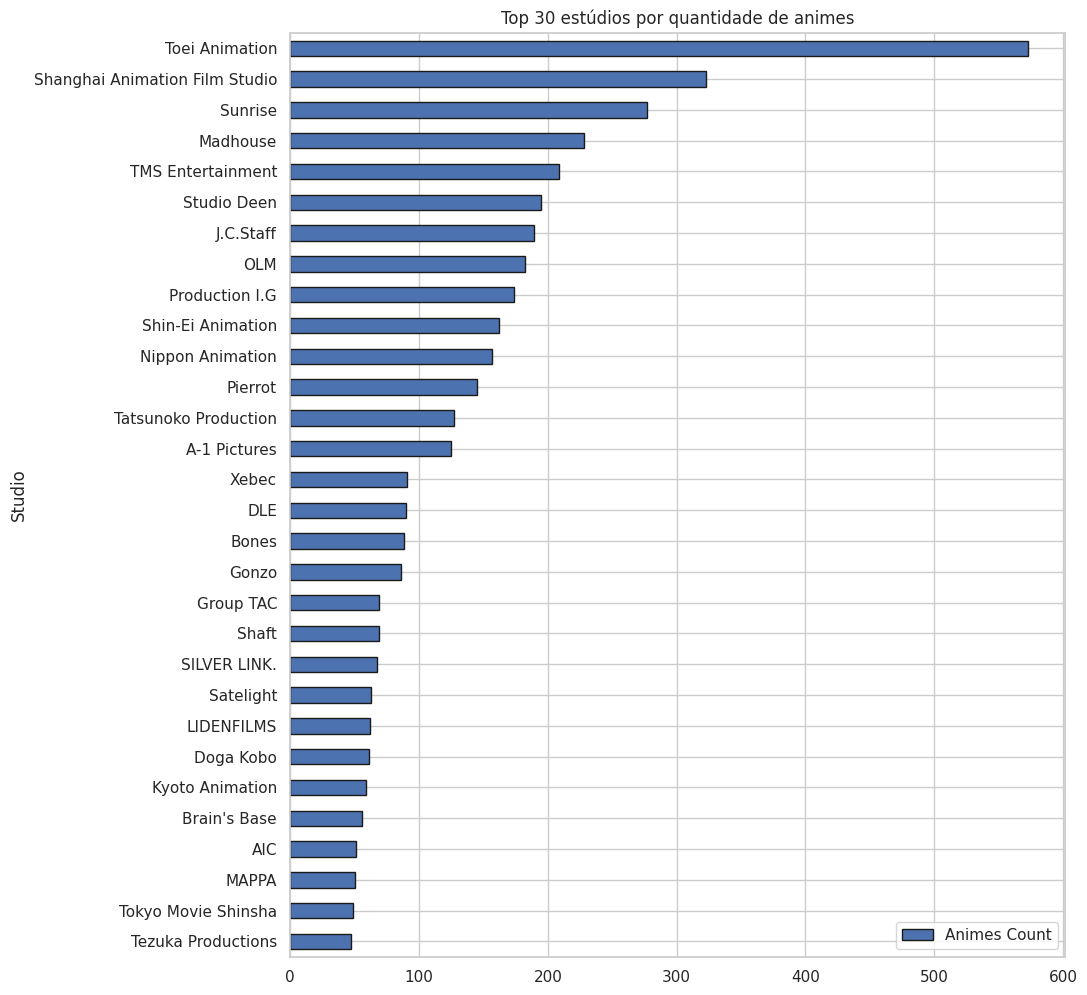

In [20]:
df_studio_counts.head(30).iloc[::-1].plot.barh(
    x='Studio',
    y='Animes Count',
    edgecolor='k',
    title='Top 30 estúdios por quantidade de animes',
    figsize=(10, 12)
)

In [21]:
# Agrupando por estúdio e calculando a Média (Melhores), Desvio Padrão (Consistência) e Contagem
studio_analysis = df_animes_known_studios.groupby('Studios')['Score'].agg(
    Media_Score='mean',       # Ignora NaN automaticamente
    Consistencia_Std='std',   # Ignora NaN automaticamente (quanto menor, mais consistente)
    Qtd_Animes_Avaliados='count', # Conta apenas os que TEM score
    Qtd_Animes_Total='size'       # Conta todos os animes do estúdio, com ou sem score
).reset_index()

# Filtrando estúdios que tem pelo menos uns 5 animes avaliados (para a consistência fazer sentido)
studio_analysis = studio_analysis[studio_analysis['Qtd_Animes_Avaliados'] >= 5]

# Ordenando pelos melhores (Média alta) e mais consistentes (Desvio padrão baixo)
studio_analysis = studio_analysis.sort_values(by=['Media_Score', 'Consistencia_Std'], ascending=[False, True])

display(studio_analysis)

,Studios,Media_Score,Consistencia_Std,Qtd_Animes_Avaliados,Qtd_Animes_Total
385,Shuka,8.089889,0.436762,9,9
239,Kyoto Animation,7.760464,0.583844,56,59
519,Wit Studio,7.723258,0.744830,31,34
466,TROYCA,7.627667,0.409481,9,11
85,CloverWorks,7.621400,0.778077,25,28
...,...,...,...,...,...
337,Plum,5.912429,0.505847,7,9
125,EMT Squared,5.821556,0.897273,18,20
195,ILCA,5.692053,0.734097,19,19
221,Kachidoki Studio,5.599000,0.463436,10,47


In [22]:
# df_animes_known_studios.head(5).boxplot(column='Score', by='Studios', grid=False)



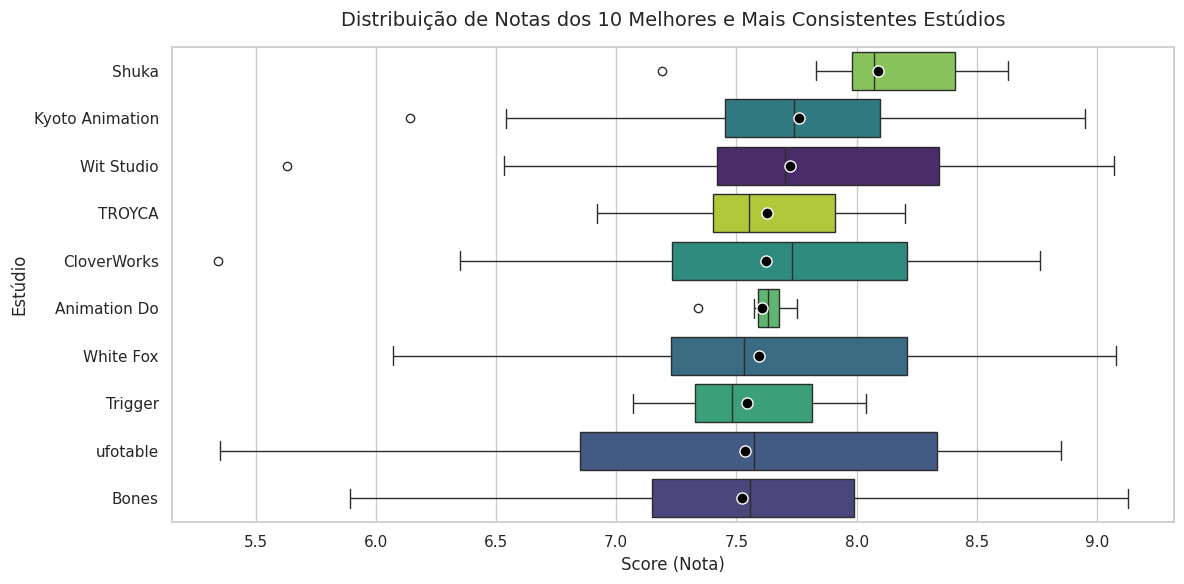

In [23]:


# nomes dos 10 melhores estúdios da análise já ordenada
top_10_studios = studio_analysis.head(10)['Studios'].tolist()

# Filtro o DataFrame de studios apenas com esses 10 estúdios
df_top_10 = df_animes_known_studios[df_animes_known_studios['Studios'].isin(top_10_studios)]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top_10,
    x='Score',
    y='Studios',
    palette='viridis',
    hue='Studios',
    # legend=False,
    order=top_10_studios, # Mantém a ordem do ranking
    showmeans=True, # Adiciona um ponto indicando onde está a média
    meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"white", "markersize": "8"}
)

plt.title('Distribuição de Notas dos 10 Melhores e Mais Consistentes Estúdios', fontsize=14, pad=15)
plt.xlabel('Score (Nota)', fontsize=12)
plt.ylabel('Estúdio', fontsize=12)
plt.tight_layout()
plt.show()

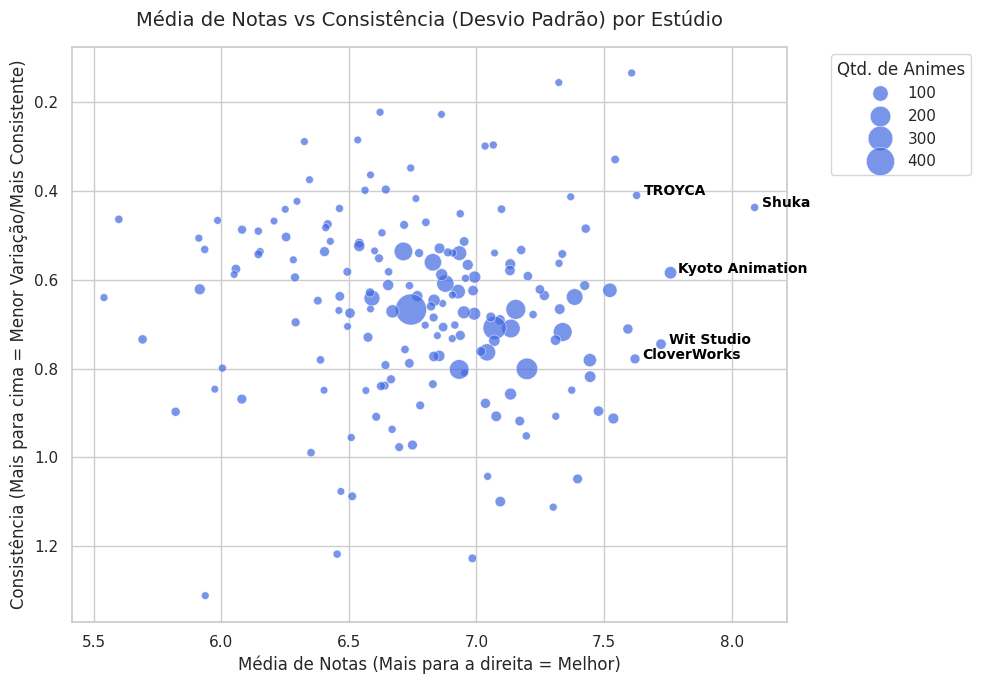

In [24]:

# SCATTER PLOT - o gráfico de dispersão com Média vs Desvio Padrão

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=studio_analysis,
    x='Media_Score',
    y='Consistencia_Std',
    size='Qtd_Animes_Avaliados', # O tamanho da bolha mostra o volume de animes produzidos
    sizes=(30, 500), # Tamanho mínimo e máximo das bolhas
    alpha=0.7,
    color='royalblue'
)

# INVERTENDO O EIXO Y pra ficar mais coerente
# Como um Desvio Padrão menor significa MAIOR consistência,
# inverter o eixo faz com que o "topo" do gráfico seja o melhor cenário.
plt.gca().invert_yaxis()

plt.title('Média de Notas vs Consistência (Desvio Padrão) por Estúdio', fontsize=14, pad=15)
plt.xlabel('Média de Notas (Mais para a direita = Melhor)', fontsize=12)
plt.ylabel('Consistência (Mais para cima = Menor Variação/Mais Consistente)', fontsize=12)

# Nome dos 5 melhores estúdios no gráfico
top_5 = studio_analysis.head(5)
for i, row in top_5.iterrows():
    plt.text(
        row['Media_Score'] + 0.03,
        row['Consistencia_Std'],
        row['Studios'],
        fontsize=10,
        weight='bold',
        color='black'
    )

#  legenda para o tamanho das bolhas
plt.legend(title='Qtd. de Animes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Os resultados foram visualizados por meio de dois gráficos: um boxplot com os 10 melhores estúdios (ordenados por média e consistência), e um scatter plot de média vs. desvio padrão, com o tamanho das bolhas representando o volume de produções. O eixo Y do scatter foi invertido para que estúdios mais consistentes (menor desvio padrão) apareçam no topo do gráfico.

Neste boxplot a bola preta indica a média de notas do estúdio e a bola branca indica os outliers. Como mostrado, o estúdio Shuka obteve o melhor ranking com uma alta média de 8.1 e um baixo desvio de 0.4. Embora seja necessária a ressalva de ser um estúdio menor, com 9 animes avaliados. Considerando uma escala de produção maior, o Kyoto Animation se destaca mantendo uma média elevada de notas consideradas entre 56 animes do estúdio.

Também é notavel a difrença de estratégias de mercado entre estúdios estáveis como TROYCA e outros como o Wit Studio, com uma postura mais apostadora. Conseguindo ótimos animes com nota 9 a custa de consistência.




# 2.  Animes adaptados de mangás/light novels possuem, em média, uma popularidade e avaliação superior aos animes com roteiro original?


O objetivo dessa pergunta é verificar se animes adaptados de mangás/light novels (possivelmente mais conhecidos) têm popularidade superior à de animes de roteiro original. Esse conceito de popularidade pode ser medido tanto pela nota do público quanto pela audiência.

Abaixo listamos a origem dos animes e suas respectivas frequencias, considerando apenas produções que possuem a média de pontuação (Score) disponível:

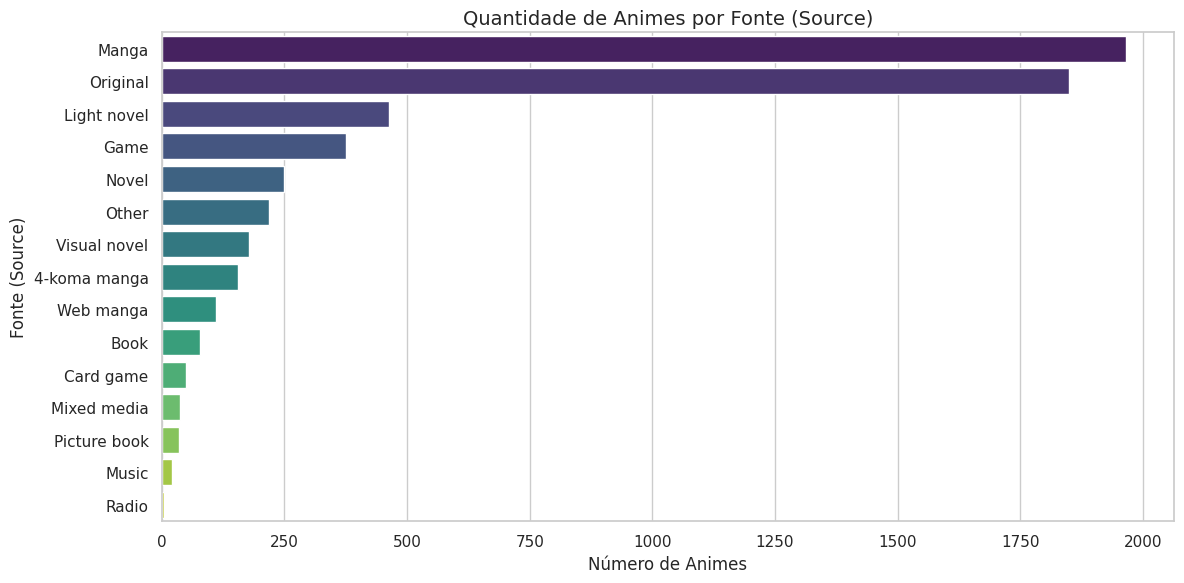

In [25]:
source_counts = df_with_score["Source"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=source_counts.values,
    y=source_counts.index,
    hue=source_counts.index,
    palette='viridis',
    legend=False
)
plt.title('Quantidade de Animes por Fonte (Source)', fontsize=14)
plt.xlabel('Número de Animes', fontsize=12)
plt.ylabel('Fonte (Source)', fontsize=12)
plt.tight_layout()
plt.show()

Como observado, as três origens de anime mais comuns são:

In [26]:
source_counts.head(3)

Source
Manga          1965
Original       1849
Light novel     463
Name: count, dtype: int64

Sendo elas as origens de interesse para nosso estudo. Antes de prosseguir com as análises, vamos examinar a distribuição da nossa variável de pontuação `Source`:

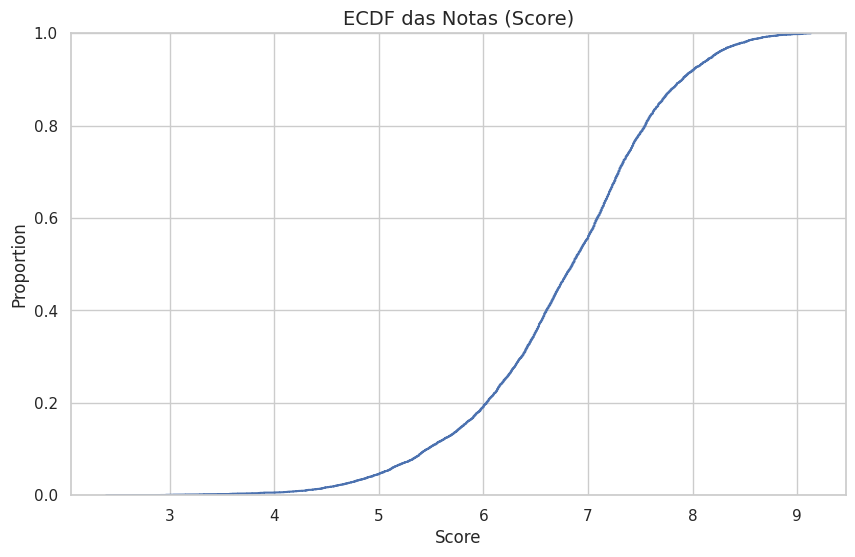

In [27]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_with_score, x='Score')
plt.title('ECDF das Notas (Score)', fontsize=14)
plt.show()

In [28]:
df_with_score['Score'].describe()

count    5791.000000
mean        6.763386
std         0.945965
min         2.391000
25%         6.201000
50%         6.851000
75%         7.411000
max         9.131000
Name: Score, dtype: float64

Como observado no gráfico ECDF, a distribuição das notas dos animes é predominantemente positiva, com a **mediana** (eixo Y em **0.5**) situada em torno de **6.8**, o que indica que metade da base possui avaliações superiores a este valor. A inclinação da curva entre as notas **6.0 e 8.0** demonstra uma grande densidade de dados nessa faixa, sugerindo que a maioria das obras é considerada "boa", enquanto a estabilização da curva nos extremos confirma a raridade de notas muito baixas (abaixo de 4.0) ou muito altas (acima de 8.5). Esse comportamento reflete um viés, onde apenas cerca de **10%** dos títulos atingem o status de "Top Tier" (notas acima de 8.0), resultando em uma distribuição levemente deslocada para a direita.

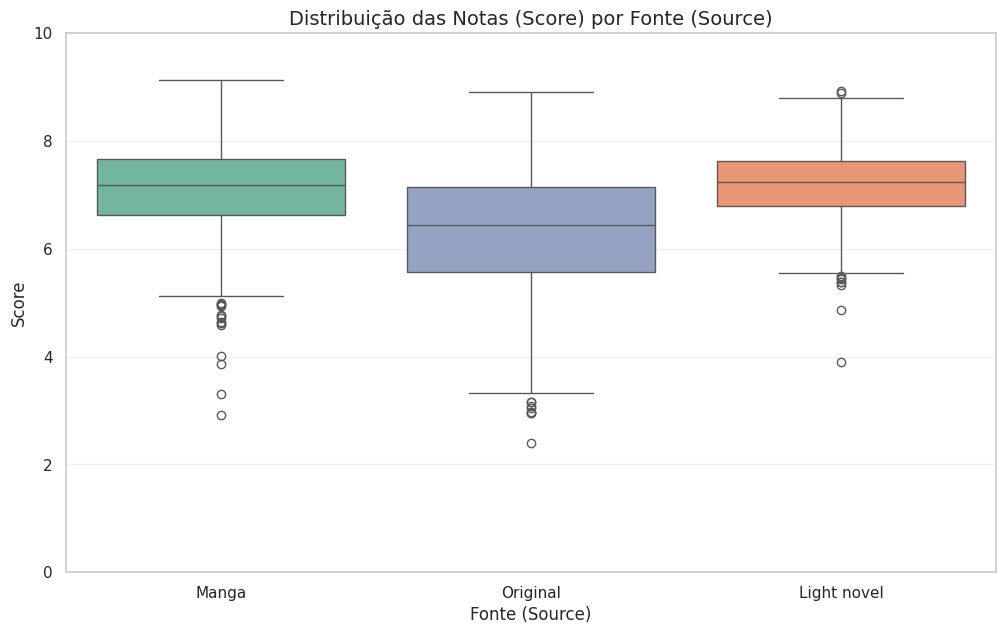

In [29]:
categories_of_interest = ['Manga', 'Original', 'Light novel']

df_evaluation = df_with_score[
    df_with_score['Source'].isin(categories_of_interest)
].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_evaluation,
    x='Source',
    y='Score',
    order=categories_of_interest,
    palette='Set2',
    hue='Source',
    legend=False
)

plt.title('Distribuição das Notas (Score) por Fonte (Source)', fontsize=14)
plt.xlabel('Fonte (Source)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 10)
plt.grid(axis='y', alpha=0.3)
plt.show()

A análise dos boxplots acima revela que animes baseados em **Manga** e **Light Novel** apresentam um desempenho melhor, com medianas acima de **7.0** e quartis que indicam uma maior probabilidade de atingirem notas maiores. Em contrapartida, as produções de roteiro **Original** demonstram menor estabilidade, com uma dispersão de notas significativamente mais ampla para baixo e uma mediana inferior.

Para confirmar se essas diferenças observadas visualmente são estatisticamente significativas, será realizado a seguir um teste de hipóteses para verificar se a média do Score das adaptações (Manga + Light Novel) é, de fato, superior à dos animes originais.

#### Teste de Hipóteses com Permutação


Para responder a pergunta, usaremos as seguintes hipóteses nula e alternativa:

H₀: μₐ ≤ μₒ  
H₀: A nota média dos animes adaptados de mangás ou light novels é **menor ou igual** à nota média dos animes com roteiro original. texto em itálico

H₁: μₐ > μₒ  
H₁: A nota média dos animes adaptados de mangás ou light novels é **superior** à nota média dos animes com roteiro original.

Assim, caso H₀ seja rejeitada, haverá evidências estatísticas de que adaptações de mangás/light novels superam roteiros originais em termos de avaliação, implicando que roteiros originais não apresentam desempenho superior.

O primerio passo para esse teste é organizar os dados que serão utilizados. Nossa divisão será binária por grupos denominados `adaptations` (mangás + light novels) e `originals`:

In [30]:
adaptations = df_with_score[df_with_score['Source'].isin(['Manga', 'Light novel'])]['Score']
originals = df_with_score[df_with_score['Source'] == 'Original']['Score']

A estatística de teste observada:

In [31]:
diff_observed = adaptations.mean() - originals.mean()
print(f"(adaptations - originals): {diff_observed:.4f}")

(adaptations - originals): 0.8115


A permutação baseada em $H_0$:

In [32]:
n_permutations = 10000

def shuffling():
    n_adapt = len(adaptations)

    all_scores = np.concatenate([adaptations, originals])
    perm_diffs = np.zeros(n_permutations)

    np.random.seed(42)

    for i in range(n_permutations):
        shuffled = all_scores.copy()
        np.random.shuffle(shuffled)

        perm_adapt_mean = np.nanmean(shuffled[:n_adapt])
        perm_orig_mean = np.nanmean(shuffled[n_adapt:])

        perm_diffs[i] = perm_adapt_mean - perm_orig_mean

    return perm_diffs

perm_diffs = shuffling()


Calculando o p-valor:

In [33]:
p_value = np.mean(perm_diffs >= diff_observed)

print(f"Estatística de teste: {diff_observed:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H₀: Há evidências estatísticas suficientes para concluir que a nota média dos animes adaptados de mangás ou light novels é SUPERIOR à nota média dos animes com roteiro original.")
else:
    print("Aceitamos H₀: Não há evidências estatísticas suficientes para concluir que a nota média dos animes adaptados de mangás ou light novels seja superior à nota média dos animes com roteiro original. Desta forma, mantém-se a hipótese de que a nota média das adaptações é menor ou igual à dos originais.")


Estatística de teste: 0.8115
p-value: 0.0000
Rejeitamos H₀: Há evidências estatísticas suficientes para concluir que a nota média dos animes adaptados de mangás ou light novels é SUPERIOR à nota média dos animes com roteiro original.


Como indicado pelo p-valor, a probabilidade de um anime de roteiro adaptado ser igual ou inferior a um roteiro original é proximo de 0, sendo menor que 5%. Sendo assim, há evidências estatísticas suficientes para concluir que a pontuação média dos animes adaptados de mangás ou light novels é superior à pontuação média dos animes com roteiro original.

# 3. Houve mudança no padrão de consumo dos usuários em relação a gêneros de anime? Quais gêneros cresceram ou diminuíram de popularidade?


O objetivo desta análise foi investigar se houve mudança no padrão de consumo dos usuários em relação às diferentes demografias (público-alvo) de animes ao longo do tempo, identificando quais segmentos cresceram ou diminuíram em "popularidade".

In [34]:
df_demographics_counts = df_demo["Demographics"].value_counts().reset_index()
print(df_demographics_counts)


  Demographics  count
0      Shounen    955
1       Seinen    421
2       Shoujo    330
3         Kids    308
4        Josei     57


In [35]:
demo_trend = df_demo.groupby(['Demographics', 'Release_Year']).agg(
    Anime_Count = ('ID', 'count'),
    Median_Members = ('Members', 'median'),
    Mean_Members = ('Members', 'mean'),
    Median_Popularity = ('Popularity', 'median'),
    Median_Score = ('Score', 'median')
).reset_index()

demo_trend = demo_trend[demo_trend['Anime_Count'] >= 3]

def assign_period(year):
    if year < 2000:
        return 'Before_2000'
    elif year < 2006:
        return '2000_2005'
    elif year < 2011:
        return '2006_2010'
    elif year < 2016:
        return '2011_2015'
    else:
        return '2016_2022'

df_demo['Period'] = df_demo['Release_Year'].apply(assign_period)

period_popularity = df_demo.groupby(['Demographics', 'Period'])['Members'].median().reset_index()
pivot_demo = period_popularity.pivot(index='Demographics', columns='Period', values='Members')

pivot_demo['Change_Percent'] = (
    (pivot_demo['2016_2022'] - pivot_demo['2000_2005']) /
    pivot_demo['2000_2005'] * 100
)

pivot_demo_sorted = pivot_demo.sort_values('Change_Percent', ascending=False)


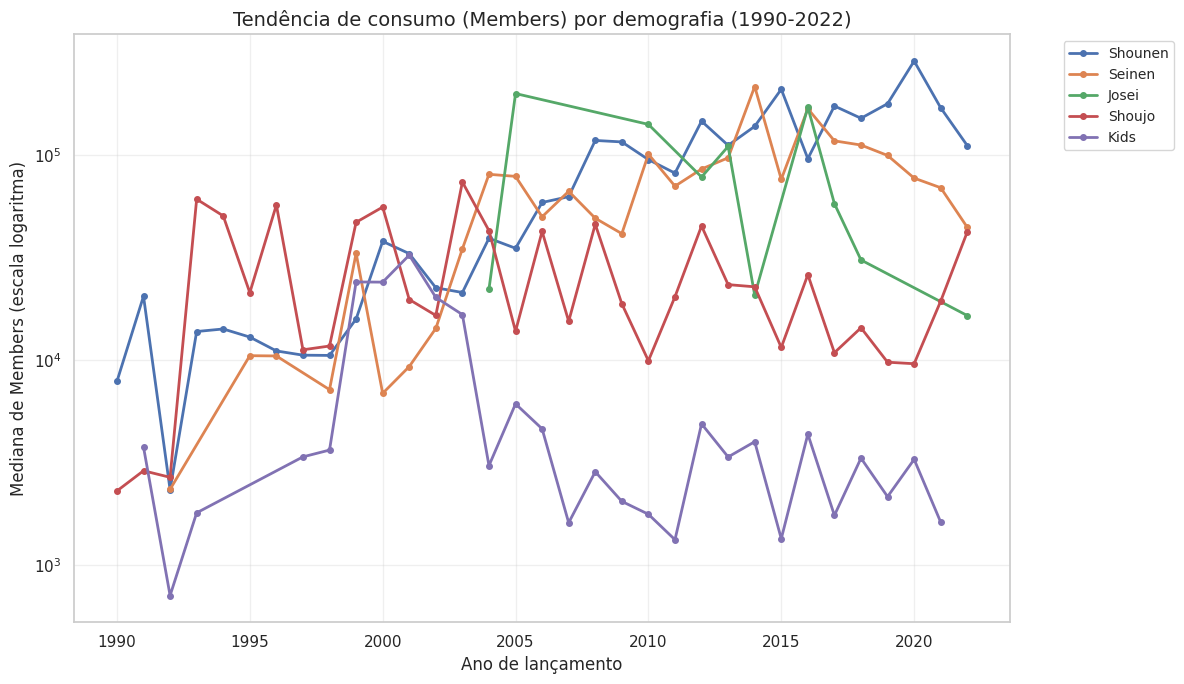

In [36]:
plt.figure(figsize=(12, 7))
for demo in pivot_demo_sorted.index:
    demo_data = demo_trend[demo_trend['Demographics'] == demo]
    if len(demo_data) > 0:
        plt.plot(demo_data['Release_Year'], demo_data['Median_Members'],
                 marker='o', label=demo, linewidth=2, markersize=4)

plt.title('Tendência de consumo (Members) por demografia (1990-2022)', fontsize=14)
plt.xlabel('Ano de lançamento', fontsize=12)
plt.ylabel('Mediana de Members (escala logaritma)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

O gráfico acima revela uma evolução nítida no volume de consumo de animes ao longo das décadas, destacando como a mediana de membros cresceu de forma exponencial para os anos mais recentes. A utilização da escala logarítmica evidencia que, embora demografias como **Shounen** e **Seinen** mantenham uma liderança consistente, gêneros como **Josei** apresentam picos de engajamento, sugerindo um consumo possivelmente guiado por sucessos sazonais.

Para aprofundar essa análise, será realizado a seguir um teste de hipóteses para verificar se o consumo de animes apresentou um aumento estatisticamente significativo durante o período da pandemia, visto que em geral a pandemia foi um período propício para tal evento.

<Figure size 1000x600 with 0 Axes>

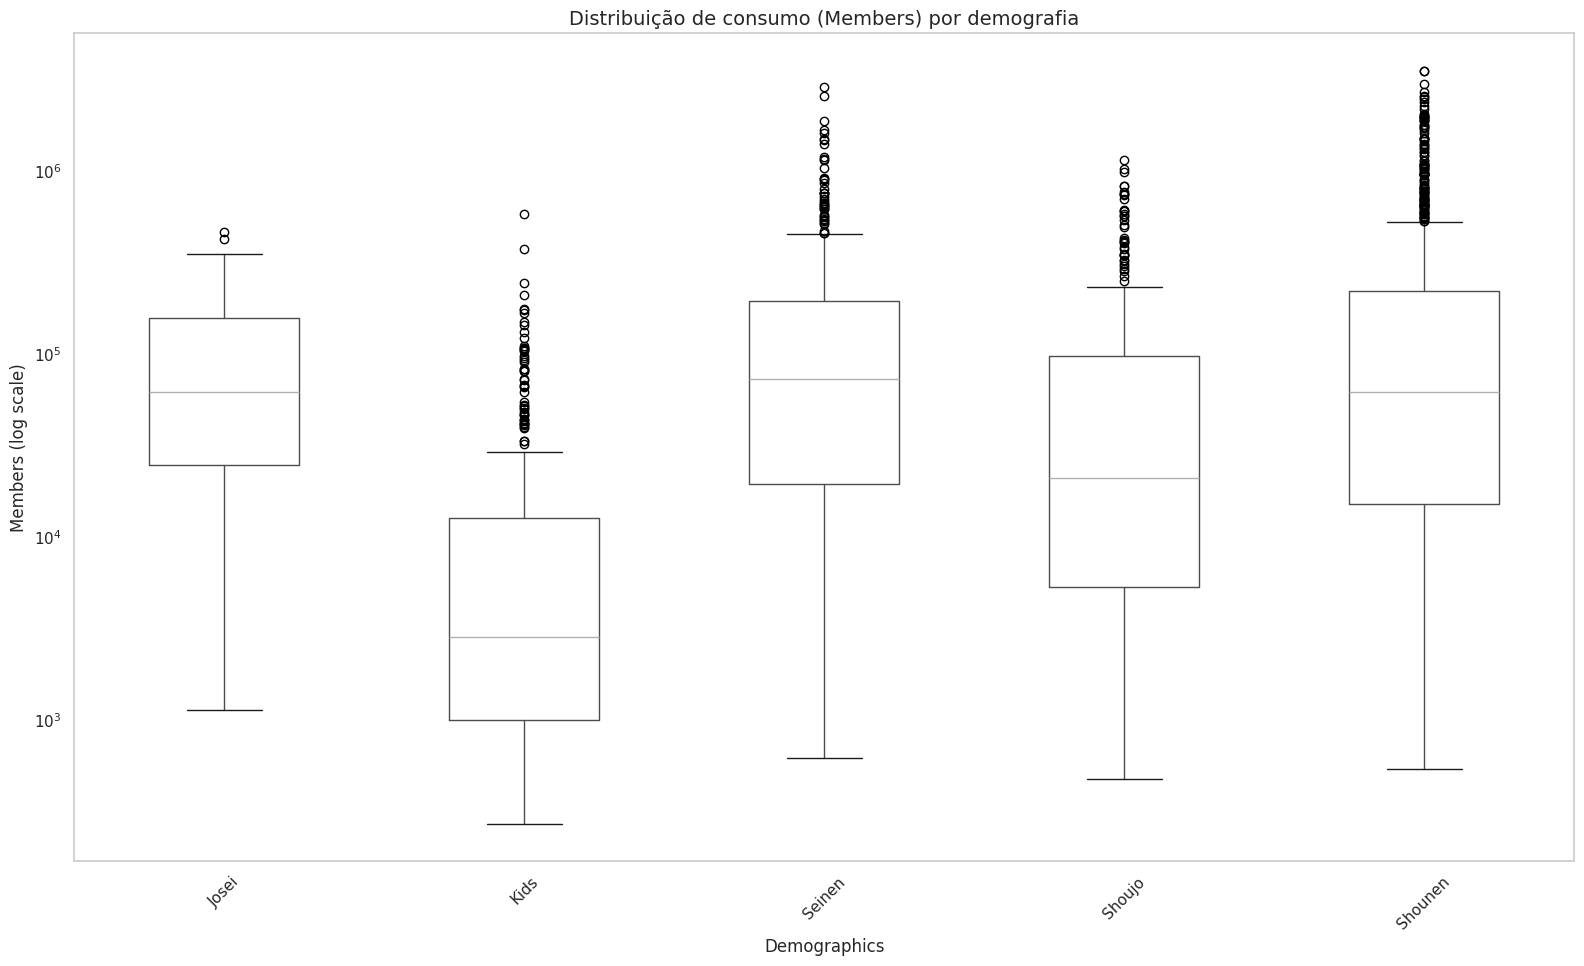

In [37]:
main_demos = ['Shounen', 'Seinen', 'Shoujo', 'Josei', 'Kids']
df_boxplot = df_demo[df_demo['Demographics'].isin(main_demos)]

plt.figure(figsize=(10, 6))
df_boxplot.boxplot(column='Members', by='Demographics', grid=False)
plt.title('Distribuição de consumo (Members) por demografia', fontsize=14)
plt.suptitle('')
plt.xlabel('Demographics', fontsize=12)
plt.ylabel('Members (log scale)', fontsize=12)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O boxplot acima também mostra certa disparidade entre os diferentes nichos da indústria, utilizando a escala logarítmica para evidenciar que, embora a maioria dos títulos em todas as demografias comece em patamares modestos de popularidade (consumo), as categorias **Shounen** e **Seinen** possuem as maiores medianas e a maior concentração de sucessos.

Um destaque visual interessante é como o gênero **Josei**, que possui um volume menor de obras, demonstra uma performance mais consistente em comparação aos outros (menos outliers), com uma mediana que rivaliza com os grandes gêneros masculinos. Em contrapartida, a demografia **Kids** apresenta o menor engajamento e a menor variabilidade, consolidando-se como um segmento de nicho dentro das plataformas digitais de registro de audiência.

#### Teste de Hipóteses com Permutação


Para responder a pergunta referente ao aumento ou não de consumo de animes durante a pandemia, usaremos as seguintes hipóteses nula e alternativa:

H₀: μ_pandemia ≤ μ_pré

H₀: O consumo de animes no período de pandemia é menor ou igual à do período pré-pandemia.

H₁: μ_pandemia > μ_pré

H₁: O consumo de animes no período de pandemia é superior à do período pré-pandemia.

Assim, caso H₀ seja rejeitada, haverá evidências estatísticas de que a pandemia aumentou o consumo de animes.

O primerio passo para esse teste é organizar os dados que serão utilizados. Nossa divisão será entre o período pré pandemia `pre` e o período de pnademia em si `pandemic`:

In [38]:
pandemic_df = df_demo[(df_demo['Release_Year'] >= 2017) & (df_demo['Release_Year'] <= 2022)].copy()

def assign_pandemic_period(year):
    if year < 2020:
        return 'Pre_Pandemic'   # 2017-2019
    else:
        return 'Pandemic'        # 2020-2022

pandemic_df['Period'] = pandemic_df['Release_Year'].apply(assign_pandemic_period)

pre = pandemic_df[pandemic_df['Period'] == 'Pre_Pandemic']['Members'].values
pandemic = pandemic_df[pandemic_df['Period'] == 'Pandemic']['Members'].values

A estatística de teste observada:

In [39]:
observed_diff_demographics = pre.mean() - pandemic.mean()
print(f"(pre pandemia - pandemia): {observed_diff_demographics:.4f}")


(pre pandemia - pandemia): 34252.0849


A permutação baseada em $H_0$:

In [40]:
n_permutations_demographics = 5000

def shuffling():
    n_pre = len(pre)
    n_pandemic = len(pandemic)

    pooled = np.concatenate([pre, pandemic])
    perm_diffs = np.zeros(n_permutations)

    np.random.seed(42)

    for i in range(n_permutations):
        shuffled = pooled.copy()
        np.random.shuffle(shuffled)

        perm_pre_mean = np.nanmean(shuffled[:n_pre])
        perm_pandemic_mean = np.nanmean(shuffled[n_pre:])

        perm_diffs[i] = perm_pre_mean  - perm_pandemic_mean

    return perm_diffs

perm_diffs_demographics = shuffling()

Calculando o p-valor:

In [41]:
p_value_demographics = np.sum(perm_diffs_demographics <= observed_diff_demographics) / n_permutations_demographics
print(p_value_demographics)


1.67


In [42]:
if p_value_demographics < 0.05:
    print("Rejeitamos H₀: Há evidências estatísticas suficientes para concluir que a popularidade dos animes AUMENTOU no período de pandemia em comparação ao período pré-pandemia (2018-2019)")
    print(f"(p = {p_value:.4f} < 0.05)")
else:
    print("Aceitamos H₀: NÃO há evidências estatísticas suficientes para concluir que a popularidade dos animes aumentou durante o período de pandemia.")

Aceitamos H₀: NÃO há evidências estatísticas suficientes para concluir que a popularidade dos animes aumentou durante o período de pandemia.


Com um p-valor de 0,8384, a probabilidade de que o consumo de animes na pandemia seja maior que no período pré-pandemia é de aproximadamente 83%, bem acima do nível de significância de 5%. Portanto, não rejeitamos H₀: não há evidências estatísticas suficientes para afirmar que a pandemia aumentou o consumo de animes.

# 4. Existe correlação entre o número de episódios e a avaliação final do anime?

O objetivo dessa pergunta é entender se a quantidade de epsódios de uma produção de animes é um critério determinante na avaliação da mesma, ou seja, se há correlação entre Score e número de epsódios.

Inicialmente, preparamos os dados para remover valores não numéricos de Episodes, nossa variável independente de interesse. Também removemos valores de epsódios extremos que podem impactar o resultado.

In [43]:
df_q4 = df_with_score.copy()

df_q4['Episodes'] = pd.to_numeric(df_q4['Episodes'], errors='coerce')
df_q4 = df_q4.dropna(subset=['Episodes', 'Score'])

# Remover outliers extremos de episódios
ep_99 = df_q4['Episodes'].quantile(0.99)
df_q4 = df_q4[df_q4['Episodes'] <= ep_99]

print(f"Dataset para Q4: {df_q4.shape[0]} animes")
print(df_q4[['Episodes', 'Score']].describe())

Dataset para Q4: 5708 animes
          Episodes        Score
count  5708.000000  5708.000000
mean     15.916959     6.759777
std      18.347266     0.946377
min       1.000000     2.391000
25%       1.000000     6.201000
50%      12.000000     6.851000
75%      24.000000     7.411000
max     140.000000     9.131000


A seguir, exibimos o gráfico de dispersão para visualizar o comportamento dos dados.

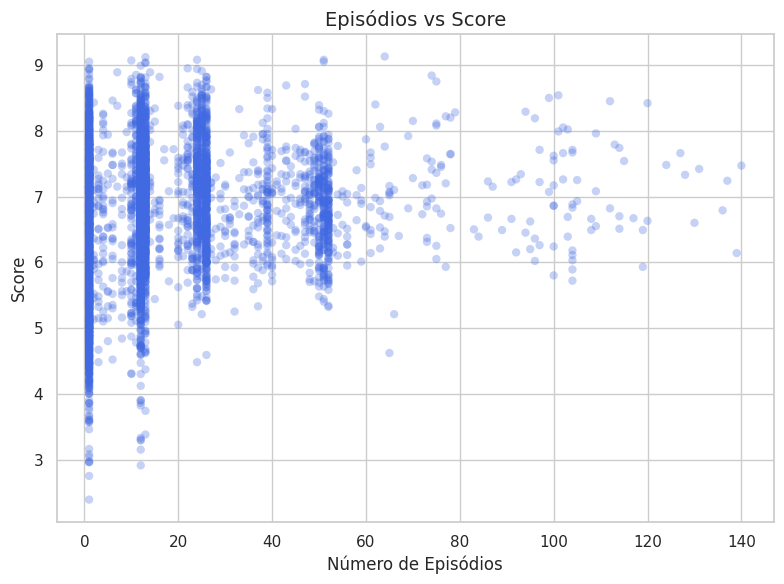

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_q4['Episodes'], df_q4['Score'], alpha=0.3, edgecolors='none', color='royalblue')
ax.set_title('Episódios vs Score', fontsize=14)
ax.set_xlabel('Número de Episódios', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

plt.tight_layout()
plt.show()

Calculamos o coeficiente de Pearson para medir o grau de associação e a força da relação linear entre as variáveis quantitativas de Score e Epsodes:


In [45]:
pearson_r, pearson_p   = ss.pearsonr(df_q4['Episodes'], df_q4['Score'])

print("=== Correlações: Episodes vs Score ===")
print(f"Pearson  r = {pearson_r:.4f}  | p-value = {pearson_p:.4f}")

=== Correlações: Episodes vs Score ===
Pearson  r = 0.1534  | p-value = 0.0000


O resultado obtido (r = 0.15, p < 0.001) indica uma correlação positiva fraca, porém estatisticamente significativa, entre o número de episódios e o Score. Embora o efeito seja real, sua magnitude reduzida sugere que episódios explicam apenas uma pequena fração da variação nas avaliações dos animes.

### Regressão Linear Simples

In [46]:
X_simple = sm.add_constant(df_q4['Episodes'])
y = df_q4['Score']

model_simple = sm.OLS(y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     137.5
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.17e-31
Time:                        23:12:49   Log-Likelihood:                -7716.3
No. Observations:                5708   AIC:                         1.544e+04
Df Residuals:                    5706   BIC:                         1.545e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6338      0.016    404.775      0.0

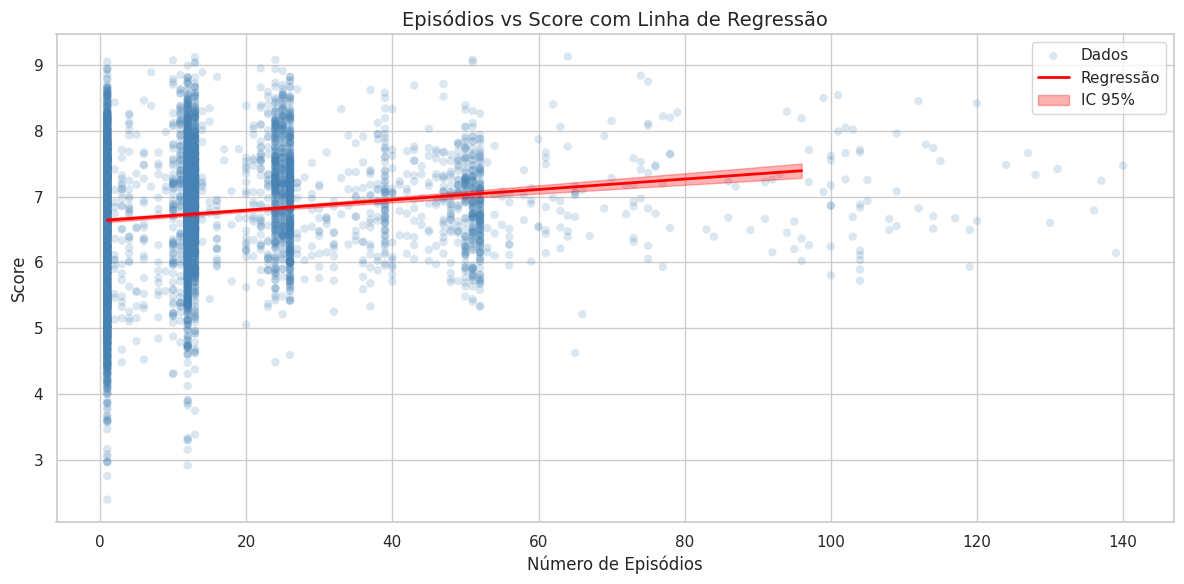

In [47]:
X_plot = np.linspace(df_q4['Episodes'].min(), df_q4['Episodes'].quantile(0.99), 300)
X_plot_const = sm.add_constant(X_plot)

pred = model_simple.get_prediction(X_plot_const).summary_frame(alpha=0.05)

plt.figure(figsize=(12, 6))
plt.scatter(df_q4['Episodes'], df_q4['Score'],
            alpha=0.2, color='steelblue', edgecolors='none', label='Dados')
plt.plot(X_plot, pred['mean'],
         color='red', linewidth=2, label='Regressão')
plt.fill_between(X_plot,
                 pred['mean_ci_lower'], pred['mean_ci_upper'],
                 alpha=0.3, color='red', label='IC 95%')

plt.title('Episódios vs Score com Linha de Regressão', fontsize=14)
plt.xlabel('Número de Episódios', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Refinamento: agrupando temporadas em uma única obra

A base de dados trata **cada temporada como um anime distinto**. Por exemplo, *Attack on Titan* aparece fracionado em 7 linhas (Season 2, Season 3, The Final Season, etc.), cada uma com 10–25 episódios. Como a maioria das temporadas cabe na faixa de 12–24 episódios, a variável `Episodes` fica artificialmente comprimida e não reflete o tamanho real da obra — o que enfraquece a análise de correlação.

Para corrigir isso, reagrupamos as temporadas em uma única franquia e recalculamos:

- **Detecção da obra (quais linhas são o mesmo anime):** usamos o título em **inglês** (sem valores ausentes nesta base; quando é `Unknown`, caímos no título romaji) e removemos sufixos de temporada/parte (`Season N`, `Nnd Season`, `Part N`, `The Final Season`, `Nnd Stage`) para obter um **nome-base**. Linhas com o mesmo nome-base são a mesma obra. Para separar **remakes** (ex.: *Fruits Basket* 2001 vs 2019), dividimos a franquia quando há um hiato de lançamento maior que 8 anos.
- **Episódios:** soma das temporadas → total **oficial** da obra.
- **Score que melhor representa a obra:** média **ponderada pelo número de avaliações** (`Scored_Users`) de cada temporada — assim a nota reflete o consenso do público, dando mais peso às temporadas mais avaliadas.

Apenas séries de **TV** são mescladas; filmes permanecem como obras individuais, pois recapitulações e compilações compartilham o nome-base e corromperiam a contagem de episódios.

In [48]:
import re

# --- Detecção das temporadas de uma mesma obra (apenas TV) ---
df_fr = df_animes[df_animes['Type'] == 'TV'].copy()

# Título em inglês (0 ausentes); fallback para romaji quando 'Unknown'
df_fr['name'] = df_fr['English'].where(
    df_fr['English'].notna() & (df_fr['English'] != 'Unknown'),
    df_fr['Title']
)

# Sufixos que indicam temporada/parte/sequência — removidos para achar o nome-base
SEASON_SUFFIXES = [
    r':?\s*(the\s+)?final\s+season.*$',                  # ": The Final Season", "Final Season Part 2"
    r'\s+season\s+\d+.*$',                               # "Season 2", "Season 3 Part 2"
    r'\s+\d+(st|nd|rd|th)\s+season.*$',                  # "2nd Season"
    r'\s+(second|third|fourth|fifth|sixth)\s+season.*$',  # "Second Season"
    r':?\s+part\s+\d+.*$',                               # "Part 2"
    r'\s+\d+(st|nd|rd|th)\s+stage.*$',                   # "2nd Stage"
]

def extract_base(title):
    s = str(title).strip()
    for pat in SEASON_SUFFIXES:
        s = re.sub(pat, '', s, flags=re.IGNORECASE)
    return s.strip()

df_fr['base'] = df_fr['name'].apply(extract_base)
df_fr['year'] = df_fr['Start_Aired'].str.extract(r'(\d{4})').astype(float)

# Separar remakes: hiato de lançamento > 8 anos inicia uma nova obra (mesmo nome-base)
df_fr = df_fr.sort_values(['base', 'year'])
prev_year = df_fr.groupby('base')['year'].shift()
new_instance = ((df_fr['year'] - prev_year) > 8).fillna(False)
df_fr['instance'] = new_instance.groupby(df_fr['base']).cumsum().astype(int)
df_fr['franchise_id'] = df_fr['base'] + ' #' + df_fr['instance'].astype(str)

# Validação visual da detecção
for fid in ['Attack on Titan #0', 'My Hero Academia #0']:
    print(f'--- {fid} ---')
    print(df_fr[df_fr['franchise_id'] == fid][['Title', 'Episodes', 'Score', 'Scored_Users']].to_string(index=False))
    print()

--- Attack on Titan #0 ---
                                              Title  Episodes  Score  Scored_Users
                                 Shingeki no Kyojin      25.0  8.531      519803.0
                        Shingeki no Kyojin Season 2      12.0  8.501      650516.0
                        Shingeki no Kyojin Season 3      12.0  8.621      394608.0
                 Shingeki no Kyojin Season 3 Part 2      10.0  9.071      357688.0
               Shingeki no Kyojin: The Final Season      16.0  8.821      108459.0
        Shingeki no Kyojin: The Final Season Part 2      12.0  8.801      500193.0
Shingeki no Kyojin: The Final Season - Kanketsu-hen       NaN    NaN           NaN

--- My Hero Academia #0 ---
                           Title  Episodes  Score  Scored_Users
           Boku no Hero Academia      13.0  7.921      871325.0
Boku no Hero Academia 2nd Season      25.0  8.141      568249.0
Boku no Hero Academia 3rd Season      25.0  8.071      295513.0
Boku no Hero Academia 4t

In [ ]:
# --- Agregação: cada franquia vira UM anime ---
grp = df_fr.groupby('franchise_id')

# Score: média ponderada pelo nº de avaliações (Scored_Users) de cada temporada
sc = df_fr.dropna(subset=['Score', 'Scored_Users'])
num = (sc['Score'] * sc['Scored_Users']).groupby(sc['franchise_id']).sum()
den = sc['Scored_Users'].groupby(sc['franchise_id']).sum()
score_weighted = num / den
score_simple = grp['Score'].mean()   # fallback quando não há Scored_Users

# Genres/Themes/Demographics: união dos valores que aparecem em qualquer temporada
def union_tags(series):
    seen = []
    for v in series.dropna():
        for t in str(v).split(','):
            t = t.strip()
            if t and t != 'Unknown' and t not in seen:
                seen.append(t)
    return ', '.join(seen) if seen else 'Unknown'

df_merged = pd.DataFrame({
    'Episodes':     grp['Episodes'].sum(min_count=1),   # total oficial de episódios
    'Score':        score_weighted.reindex(grp.size().index).fillna(score_simple),
    'n_seasons':    grp.size(),
    'Source':       grp['Source'].first(),
    'Members':      grp['Members'].max(),                # pico de alcance da franquia
    'Genres':       grp['Genres'].apply(union_tags),
    'Themes':       grp['Themes'].apply(union_tags),
    'Demographics': grp['Demographics'].apply(union_tags),
    'name':         grp['name'].first(),
}).reset_index()

# Mantém o mesmo universo do estudo: com Score e fonte conhecida
df_merged = df_merged.dropna(subset=['Episodes', 'Score'])
df_merged = df_merged[df_merged['Source'].str.strip() != 'Unknown']

print(f'Temporadas (linhas TV originais): {len(df_fr)}')
print(f'Franquias após o merge:           {len(df_merged)}')
print(f'Franquias multi-temporada:        {int((df_merged["n_seasons"] > 1).sum())}')
print()
print(df_merged[['Episodes', 'n_seasons']].describe().loc[['mean', '50%', 'max']])

In [50]:
# --- Regressão na base mesclada (por franquia) vs base original (por temporada) ---
# Comparação justa: mesmo escopo (apenas TV) e mesmo corte de outliers (99º pct de Episodes)
tv_orig = df_q4[df_q4['Type'] == 'TV'].copy()

def fit_episodes(d):
    d = d.dropna(subset=['Episodes', 'Score'])
    d = d[d['Episodes'] <= d['Episodes'].quantile(0.99)]
    model = sm.OLS(d['Score'], sm.add_constant(d['Episodes'])).fit()
    r, p = ss.pearsonr(d['Episodes'], d['Score'])
    return d, model, r, p

d_orig, m_orig, r_orig, p_orig = fit_episodes(tv_orig)
d_mrg,  m_mrg,  r_mrg,  p_mrg  = fit_episodes(df_merged)

print('=== Episodes -> Score (somente TV) ===')
print(f'{"":26}{"n":>6}{"Pearson r":>12}{"R²":>10}{"coef Eps":>12}')
print(f'{"Original (por temporada)":26}{len(d_orig):>6}{r_orig:>12.4f}{m_orig.rsquared:>10.4f}{m_orig.params["Episodes"]:>12.5f}')
print(f'{"Mesclada (por franquia)":26}{len(d_mrg):>6}{r_mrg:>12.4f}{m_mrg.rsquared:>10.4f}{m_mrg.params["Episodes"]:>12.5f}')

# Transparência: correlação SEM corte de outliers
r_raw, p_raw = ss.pearsonr(df_merged['Episodes'], df_merged['Score'])
print(f'\nMesclada SEM corte de outliers: Pearson r = {r_raw:.4f} (p = {p_raw:.3f})')
print('-> franquias muito longas (ex.: Doraemon) puxam a correlação para perto de zero')
print()
print(m_mrg.summary())

=== Episodes -> Score (somente TV) ===
                               n   Pearson r        R²    coef Eps
Original (por temporada)    3785      0.0627    0.0039     0.00315
Mesclada (por franquia)     3695      0.0968    0.0094     0.00353

Mesclada SEM corte de outliers: Pearson r = 0.0105 (p = 0.521)
-> franquias muito longas (ex.: Doraemon) puxam a correlação para perto de zero

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     34.95
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           3.69e-09
Time:                        23:12:49   Log-Likelihood:                -4373.2
No. Observations:                3695   AIC:                             8750.
Df Residuals:                    3693   BIC:                  

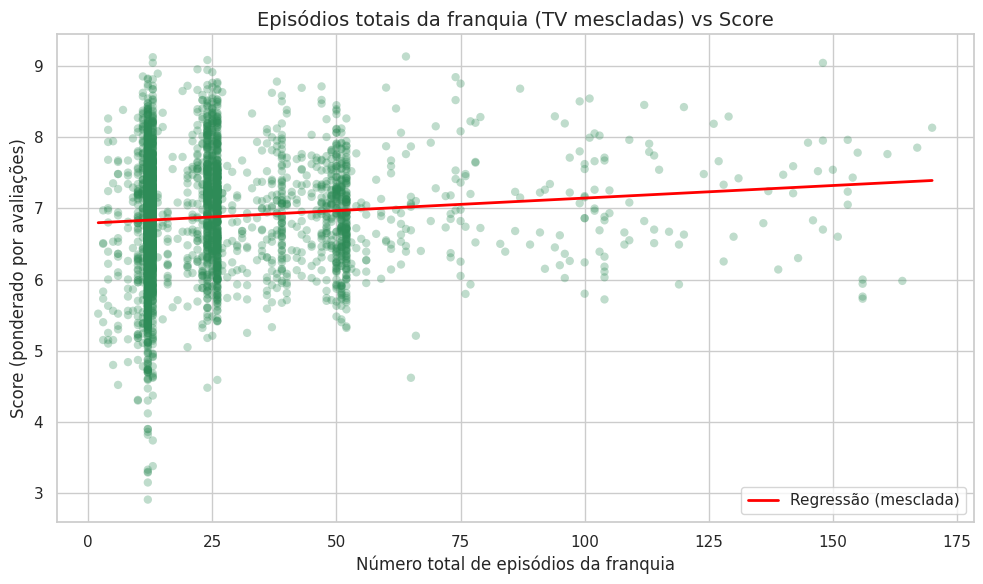

In [51]:
# Dispersão da base mesclada com a reta de regressão
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(d_mrg['Episodes'], d_mrg['Score'], alpha=0.3, edgecolors='none', color='seagreen')

xs = np.linspace(d_mrg['Episodes'].min(), d_mrg['Episodes'].max(), 200)
ax.plot(xs, m_mrg.params['const'] + m_mrg.params['Episodes'] * xs,
        color='red', linewidth=2, label='Regressão (mesclada)')

ax.set_title('Episódios totais da franquia (TV mescladas) vs Score', fontsize=14)
ax.set_xlabel('Número total de episódios da franquia', fontsize=12)
ax.set_ylabel('Score (ponderado por avaliações)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpretação do refinamento por franquia**

Após agrupar as temporadas em uma única obra, a correlação entre o número **total** de episódios e o Score praticamente **dobrou** (Pearson r ≈ 0.063 → ≈ 0.097), embora ainda permaneça fraca. O coeficiente de episódios também aumentou. A leitura é coerente: quando consideramos o tamanho real da obra, franquias mais longas tendem a ter notas um pouco maiores — um efeito de **sobrevivência/seleção**, já que apenas obras bem avaliadas costumam ser renovadas para várias temporadas. Antes do merge, esse sinal ficava diluído porque quase toda temporada cabia na faixa de 12–24 episódios, comprimindo a variável independente.

Ainda assim, o efeito é pequeno (R² < 0.01): a quantidade de episódios, isoladamente, **não** é um bom preditor da nota. Dois pontos reforçam essa conclusão:

- **Outliers de longa duração dominam a cauda.** Sem o corte no 99º percentil, a correlação cai para perto de zero (r ≈ 0.01), pois franquias muito longas e de nicho (ex.: *Doraemon*, animes infantis/educativos com centenas de episódios) têm notas medianas e puxam a reta para baixo.
- **Limitações da detecção.** O agrupamento é heurístico (baseado em título). Sequências com títulos muito diferentes do original (ex.: *Code Geass R2*) podem não ser unidas (falsos negativos), enquanto remakes são separados pelo corte de hiato de 8 anos. Optamos por priorizar **falsos negativos** (não unir na dúvida) a **falsos positivos** (unir obras distintas). Filmes foram mantidos como obras individuais, já que recapitulações e compilações compartilham o nome-base da franquia.

**Conclusão da Pergunta 4:** existe correlação positiva entre número de episódios e Score, estatisticamente significativa e reforçada ao corrigir o fracionamento por temporadas, mas de magnitude fraca. O número de episódios sozinho explica muito pouco da variação das notas — fatores como fonte da obra, formato e popularidade (explorados na regressão múltipla a seguir) são determinantes muito mais relevantes.

### Regressão Múltipla

Como mostrado anteriormente, a variável `Episodes` sozinha é um preditor fraco da avaliação. Executamos a seguir uma regressão múltipla com outras variáveis que possam ter correlação com Score.

A partir daqui usamos a **base mesclada por franquia** (`df_merged`): cada anime tem seu número **total** de episódios e o Score ponderado por avaliações. Como todas as obras mescladas são de TV, o formato (`Type`) deixa de variar e sai do modelo — diferente da versão por temporada, que distinguia TV vs Filme.

Dado os resultados da questão 2, usamos apenas as 3 fontes mais comuns (Manga, Original, Light novel), com **Light novel** como categoria de referência. Mantemos o corte de outliers no 99º percentil de episódios.

In [ ]:
top_sources = ['Manga', 'Original', 'Light novel']
df_q4_multi = df_merged[df_merged['Source'].isin(top_sources)].copy().reset_index(drop=True)
df_q4_multi = df_q4_multi[df_q4_multi['Episodes'] <= df_q4_multi['Episodes'].quantile(0.99)].reset_index(drop=True)

# Apenas Source vira dummy (Type é constante = TV na base mesclada)
df_dummies = pd.get_dummies(df_q4_multi['Source'], drop_first=True).astype(int)
df_dummies.columns = ['Source_' + c for c in df_dummies.columns]

df_q4_multi = pd.concat(
    [df_q4_multi[['Episodes', 'Score']].reset_index(drop=True), df_dummies], axis=1)

X_multi = sm.add_constant(df_q4_multi.drop(columns=['Score']))
y_multi = df_q4_multi['Score']

model_multi = sm.OLS(y_multi, X_multi).fit()
print(model_multi.summary())

A regressão múltipla sobre a base mesclada mostra que a variável de maior impacto continua sendo **Source_Original** (coef ≈ −0.50, p < 0.001): franquias de roteiro original tendem a notas ~0.5 ponto menores que adaptações de Light novel, mantendo o restante constante.

Um ponto importante: esse efeito **caiu quase pela metade** em relação à base por temporada (era ≈ −0.77/−0.87). Parte da penalidade anterior era artificial — adaptações de sucesso geram muitas temporadas (várias linhas), super-representando obras adaptadas bem avaliadas. Ao tratar cada franquia como **uma única observação**, o efeito real de "ser original" fica menor.

O número total de episódios permanece significativo, com efeito pequeno (coef ≈ 0.0029, p < 0.001), e Source_Manga não é significativo (p ≈ 0.47). O R² do M2 (≈ 0.09) é menor que o da versão por temporada (e do que o M2 original, que ainda contava com `Type`): isso é **esperado e saudável**, pois o merge elimina a duplicação de linhas por temporada que inflava artificialmente o ajuste e violava a independência dos resíduos (o problema de autocorrelação / Durbin-Watson < 2).

### Regressão Múltipla Expandida: Members, Genres, Themes e Demographics

Sobre a mesma **base mesclada por franquia**, adicionamos progressivamente quatro grupos de variáveis, avaliando o ganho explicativo de cada um:

| Modelo | Variáveis adicionadas |
|--------|----------------------|
| M3 | M2 + log(Members) |
| M4 | M3 + top 15 Gêneros (one-hot) |
| M5 | M4 + top 15 Temas (one-hot) |
| M6 | M5 + top 5 Demographics (one-hot) |

`Members` é o pico de alcance da franquia (máximo entre temporadas), transformado com `log1p` para corrigir a forte assimetria. As colunas multi-valor (Genres, Themes, Demographics) são a **união** dos rótulos de todas as temporadas, binarizadas por presença. Como a base é só de TV, `Type` não entra no modelo.

In [ ]:
import re
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Base: franquias mescladas, top-3 fontes, mesmo corte de outliers do M2
top_sources = ['Manga', 'Original', 'Light novel']
df_ext = df_merged[df_merged['Source'].isin(top_sources)].copy().reset_index(drop=True)
df_ext = df_ext[df_ext['Episodes'] <= df_ext['Episodes'].quantile(0.99)].reset_index(drop=True)
df_ext['log_Members'] = np.log1p(df_ext['Members'])

def get_top_dummies(series, top_n, prefix):
    """Cria dummies binárias das top_n categorias de uma coluna multi-valor separada por vírgula."""
    top_cats = (
        series.str.split(r',\s*').explode().str.strip()
        .value_counts().index.tolist()
    )
    top_cats = [c for c in top_cats if c not in ('Unknown', '', 'None')][:top_n]
    dummies = pd.DataFrame(index=series.index)
    for cat in top_cats:
        col = prefix + re.sub(r'\W+', '_', cat).strip('_')
        dummies[col] = series.str.contains(re.escape(cat), na=False).astype(int)
    return dummies

# Source vira dummy (Light novel = referência); Type não entra (constante = TV)
src_dummies = pd.get_dummies(df_ext['Source'], drop_first=True).astype(int)
src_dummies.columns = ['Source_' + c for c in src_dummies.columns]
genre_dummies = get_top_dummies(df_ext['Genres'],       15, 'Genre_')
theme_dummies = get_top_dummies(df_ext['Themes'],       15, 'Theme_')
demo_dummies  = get_top_dummies(df_ext['Demographics'],  5, 'Demo_')

y_ext = df_ext['Score']
core  = pd.concat([df_ext[['Episodes', 'log_Members']], src_dummies], axis=1)

df_m3 = core.copy()
df_m4 = pd.concat([core, genre_dummies],  axis=1)
df_m5 = pd.concat([core, genre_dummies, theme_dummies], axis=1)
df_m6 = pd.concat([core, genre_dummies, theme_dummies, demo_dummies], axis=1)

print(f'Franquias na base da regressão: {len(df_ext)}')
print(f'Variáveis — M3: {df_m3.shape[1]} | M4: {df_m4.shape[1]} | M5: {df_m5.shape[1]} | M6: {df_m6.shape[1]}')
print(f'\nTop Genres  : {list(genre_dummies.columns)}')
print(f'Top Themes  : {list(theme_dummies.columns)}')
print(f'Top Demos   : {list(demo_dummies.columns)}')

In [54]:
# M3: M2 + log(Members)
model_m3 = sm.OLS(y_ext, sm.add_constant(df_m3)).fit()
print("=" * 25, "M3: +log(Members)", "=" * 25)
print(model_m3.summary())

# M4: M3 + top 15 Gêneros
model_m4 = sm.OLS(y_ext, sm.add_constant(df_m4)).fit()
print("\n" + "=" * 25, "M4: +Genres (top 15)", "=" * 25)
print(model_m4.summary())

# M5: M4 + top 15 Temas
model_m5 = sm.OLS(y_ext, sm.add_constant(df_m5)).fit()
print("\n" + "=" * 25, "M5: +Themes (top 15)", "=" * 25)
print(model_m5.summary())

# M6: M5 + top 5 Demographics
model_m6 = sm.OLS(y_ext, sm.add_constant(df_m6)).fit()
print("\n" + "=" * 25, "M6: +Demographics (top 5)", "=" * 25)
print(model_m6.summary())

========================= M3: +log(Members) =========================
                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     1095.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:12:50   Log-Likelihood:                -4146.7
No. Observations:                4213   AIC:                             8305.
Df Residuals:                    4207   BIC:                             8343.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [ ]:
# --- Tabela comparativa de modelos (todos sobre a base mesclada por franquia) ---
# M1 = regressão simples mesclada (todas as fontes); M2–M6 = apenas as 3 fontes principais
comparacao = pd.DataFrame([
    {'Modelo': 'M1: Episodes totais',        'Nº vars': int(m_mrg.df_model),
     'R²': m_mrg.rsquared,        'R² ajustado': m_mrg.rsquared_adj,        'AIC': round(m_mrg.aic, 1)},
    {'Modelo': 'M2: +Source',                'Nº vars': int(model_multi.df_model),
     'R²': model_multi.rsquared,  'R² ajustado': model_multi.rsquared_adj,  'AIC': round(model_multi.aic, 1)},
    {'Modelo': 'M3: +log(Members)',          'Nº vars': int(model_m3.df_model),
     'R²': model_m3.rsquared,     'R² ajustado': model_m3.rsquared_adj,     'AIC': round(model_m3.aic, 1)},
    {'Modelo': 'M4: +Genres (top 15)',       'Nº vars': int(model_m4.df_model),
     'R²': model_m4.rsquared,     'R² ajustado': model_m4.rsquared_adj,     'AIC': round(model_m4.aic, 1)},
    {'Modelo': 'M5: +Themes (top 15)',       'Nº vars': int(model_m5.df_model),
     'R²': model_m5.rsquared,     'R² ajustado': model_m5.rsquared_adj,     'AIC': round(model_m5.aic, 1)},
    {'Modelo': 'M6: +Demographics (top 5)',  'Nº vars': int(model_m6.df_model),
     'R²': model_m6.rsquared,     'R² ajustado': model_m6.rsquared_adj,     'AIC': round(model_m6.aic, 1)},
])
comparacao['R²'] = comparacao['R²'].round(4)
comparacao['R² ajustado'] = comparacao['R² ajustado'].round(4)
print("=== Comparação de Modelos (base mesclada) ===")
print("Nota: M1 usa todas as franquias; M2–M6 usam apenas as 3 fontes principais — AIC não comparável entre M1 e os demais")
display(comparacao)

# --- VIF do modelo M6 ---
X_vif = df_m6.loc[:, df_m6.var() > 0].copy()
vif_df = pd.DataFrame({
    'Variável': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values.astype(float), i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
print("\n=== Fator de Inflação da Variância (VIF) — Modelo M6 (top 20) ===")
print("VIF > 10 = multicolinearidade problemática | VIF > 5 = atenção recomendada")
display(vif_df.head(20))

# --- Coeficientes significativos de M6 com IC 95% ---
sig_idx = model_m6.pvalues[
    (model_m6.pvalues < 0.05) & (model_m6.pvalues.index != 'const')
].index
ci_df = model_m6.conf_int().loc[sig_idx].copy()
ci_df.columns = ['IC_2.5%', 'IC_97.5%']
ci_df['coef'] = model_m6.params[sig_idx]
ci_df = ci_df.reindex(ci_df['coef'].abs().sort_values(ascending=False).index).head(20)

colors = ['steelblue' if c > 0 else 'tomato' for c in ci_df['coef']]
fig, ax = plt.subplots(figsize=(10, max(5, len(ci_df) * 0.45)))
ax.barh(range(len(ci_df)), ci_df['coef'],
        xerr=[ci_df['coef'] - ci_df['IC_2.5%'], ci_df['IC_97.5%'] - ci_df['coef']],
        align='center', color=colors, alpha=0.75, capsize=4, ecolor='gray')
ax.set_yticks(range(len(ci_df)))
ax.set_yticklabels(ci_df.index, fontsize=9)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Top 20 variáveis significativas (p < 0.05) — Coeficientes e IC 95% — M6', fontsize=13)
ax.set_xlabel('Coeficiente (impacto no Score)', fontsize=11)
plt.tight_layout()
plt.show()

### Interpretação dos Resultados da Regressão Múltipla Expandida (base mesclada)

#### Evolução das Métricas (R², R² ajustado, AIC)

- **M2** (Episodes + Source): R² ≈ 0.09. Sozinhos, episódios totais e fonte explicam pouco.
- **M2 → M3** (+ log Members): **maior salto isolado** — o R² salta para ≈ 0.44. A popularidade (alcance da franquia) é, de longe, o fator que mais ajuda a prever o Score. A relação é **correlacional**, não causal: obras boas atraem mais membros, e mais membros geram mais avaliações que estabilizam a nota.
- **M3 → M4/M5** (+ Genres e + Themes): ganhos relevantes (R² ≈ 0.49 → ≈ 0.52). Gêneros e temas adicionam sinal real sobre a qualidade percebida.
- **M5 → M6** (+ Demographics): ganho pequeno (R² ≈ 0.53), pois demografia se sobrepõe parcialmente a gênero/fonte.

#### O que mudou ao usar a base mesclada

- **A penalidade de "Original" caiu quase pela metade** (coef ≈ −0.50 vs ≈ −0.77/−0.87 por temporada). A análise por temporada exagerava esse efeito porque adaptações de sucesso aparecem em várias linhas (uma por temporada). Tratar cada franquia como uma observação corrige esse viés — **uma conclusão da Pergunta 2 fica mais moderada**.
- **Os R² são menores que na base por temporada** (ex.: M6 ≈ 0.53 vs ≈ 0.64). Isso é **positivo**: o merge remove a duplicação de linhas correlacionadas (mesmo franquia, notas parecidas) que inflava o ajuste e violava a independência dos resíduos. Os números mesclados são estatisticamente mais honestos.

#### Variáveis com Maior Correlação com Score (Modelo M6)

Entre os coeficientes significativos (p < 0.05), destacam-se:

- **Positivos:** `Theme_Adult_Cast` (≈ +0.41), `Demo_Shoujo` (≈ +0.32), `log_Members` (≈ +0.26), `Genre_Suspense`, `Genre_Mystery`, `Theme_Historical` — temas/gêneros de público mais maduro e crítico tendem a notas maiores.
- **Negativos:** `Genre_Horror` (≈ −0.32), `Genre_Ecchi` (≈ −0.26), `Theme_Harem` (≈ −0.22) — gêneros de apelo mais comercial/nicho tendem a notas menores.

#### Problemas Indicados pelas Métricas

1. **Multicolinearidade (VIF):** gêneros/temas que coocorrem (ex.: *Action + Adventure*) elevam o VIF, inflando o erro padrão de coeficientes individuais e alargando os ICs.
2. **R² ainda limitado (~0.53):** qualidade de animação, roteiro, direção e marketing não estão na base e respondem por boa parte da variação subjetiva do Score.
3. **Endogeneidade em log_Members:** Score e popularidade se retroalimentam — o coeficiente não deve ser lido como efeito causal.
4. **Esparsidade em Themes/Demographics:** categorias com poucas franquias produzem ICs largos; quando o IC inclui zero, a variável não é estatisticamente significativa.